In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## Read in SASA data

In [3]:
bound_surf = pd.read_table('/data/kball/SH3_binding/salt_paper_analysis/AbpSH3_ArkA12/surf.dat', sep = '\s+')
ArkA12_binding_surf = pd.read_table('/data/kball/SH3_binding/binding_paper_analysis/hydrophobics/ArkA12_binding/surf.dat', sep = '\s+')
#s1_binding_surf = pd.read_table('/data/kball/SH3_binding/binding_paper_analysis/hydrophobics/seg1_binding/surf.dat', sep = '\s+')

salt_bound_surf = pd.read_table('/data/kball/SH3_binding/salt_paper_analysis/AbpSH3_ArkA12_NaCl/surf.dat', sep = '\s+')
salt_binding_surf = pd.read_table('/data/mcohen3/SH3/analysis/hbonds/dat/surf.dat', sep = '\s+')

In [4]:
ArkA12_binding_surf

,#Frame,SA_00001,SA_00002,SA_00003,SA_00004,SA_00005,SA_00006,SA_00007,SA_00008,SA_00009,SA_00010,SA_00011,SA_00012,SA_00013
0,1,5158.3144,133.3588,103.2869,127.6576,100.6401,100.6670,101.8187,118.3369,101.2219,86.6785,150.1325,129.7991,158.0267
1,2,5169.5144,136.3118,103.3053,122.3013,99.6839,102.2303,108.4543,112.2560,96.8237,81.0339,139.7976,127.6229,152.4563
2,3,5135.2332,135.3167,101.5489,130.4222,98.5793,98.5359,107.4209,116.2521,104.5396,91.1342,138.5797,130.8050,162.5830
3,4,5083.0168,135.1558,92.9387,131.1645,98.0941,102.8232,101.1190,115.5086,107.1576,82.9317,140.3299,126.7413,159.4801
4,5,5169.9587,130.2714,97.8513,130.2994,99.2146,104.7914,100.2499,118.2866,106.0593,76.9136,146.3186,129.1013,161.3503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4999995,4999996,4414.5676,26.0862,54.4950,107.8099,22.4699,77.9692,107.2908,48.0221,108.7610,82.0703,142.5541,120.6236,156.9365
4999996,4999997,4502.1892,32.4451,57.3047,104.1062,23.7167,75.6392,106.0534,70.4969,115.6848,84.4651,138.9629,133.4919,162.4869
4999997,4999998,4541.4982,22.1766,38.8482,109.6711,27.9310,78.1353,109.4303,59.2687,108.9996,83.5851,145.5622,131.2684,159.1879
4999998,4999999,4466.2501,32.3666,43.8225,120.0181,32.0282,76.5930,110.3075,55.5172,109.5038,79.0030,140.8974,131.7106,154.5326


In [5]:
arka12_stat = pd.read_csv('/data/kball/SH3_binding/binding_paper_analysis/ArkA12_status.csv')

In [6]:
salt_arka12_stat = pd.read_csv('/data/jcardoso/binding_figures_800ArkA12/ArkA12/pair_wise_distances/binding/salt/status_files/ArkA12_binding_salt_status.csv')

# No salt calculations

In [7]:
avg_surf = pd.DataFrame(columns=['ArkA12 bound sims'])
bound_surf = bound_surf.drop(['#Frame'], axis=1)
avg_surf['ArkA12 bound sims'] = bound_surf.mean()/100 # convert to nm^2
avg_surf

,ArkA12 bound sims
SA_00001,39.925176
SA_00002,0.332642
SA_00003,0.334933
SA_00004,1.215718
SA_00005,0.604560
SA_00006,0.292615
SA_00007,0.961267
SA_00008,-0.238741
SA_00009,0.195574
SA_00010,1.083884


In [8]:
std_surf = pd.DataFrame(columns=['ArkA12 bound sims'])
num_bound_sims = 10
num_bound_snapshots = int(len(bound_surf)/num_bound_sims)
avg_surf_by_sim = pd.DataFrame(columns=[0])
for sim in range(0,num_bound_sims):
    avg_surf_by_sim[sim] = bound_surf[sim*num_bound_snapshots:(sim+1)*num_bound_snapshots].mean()/100 # convert to nm^2
std_surf['ArkA12 bound sims'] = avg_surf_by_sim.sem(axis=1)
std_surf

,ArkA12 bound sims
SA_00001,0.159905
SA_00002,0.014163
SA_00003,0.004078
SA_00004,0.002005
SA_00005,0.003017
SA_00006,0.004501
SA_00007,0.001121
SA_00008,0.035319
SA_00009,0.009120
SA_00010,0.013415


In [9]:
avg_surf_by_sim

,0,1,2,3,4,5,6,7,8,9
SA_00001,39.431674,39.756915,40.107365,39.951854,41.145772,40.116822,39.767010,39.362752,40.028385,39.583209
SA_00002,0.329514,0.324005,0.329581,0.299747,0.294095,0.437096,0.379220,0.335066,0.294111,0.303985
SA_00003,0.333045,0.329455,0.326047,0.340142,0.355341,0.323864,0.321086,0.330535,0.359184,0.330631
SA_00004,1.216106,1.208614,1.216253,1.219300,1.229942,1.208472,1.213381,1.211187,1.219625,1.214303
SA_00005,0.606449,0.600356,0.612997,0.597130,0.615702,0.621947,0.598170,0.597736,0.592087,0.603029
SA_00006,0.285797,0.274883,0.288544,0.292527,0.325900,0.295053,0.281934,0.289471,0.305632,0.286411
SA_00007,0.961031,0.956958,0.956874,0.959125,0.963189,0.968213,0.958423,0.962052,0.962761,0.964039
SA_00008,-0.375886,-0.311946,-0.171129,-0.178607,-0.005200,-0.180779,-0.260852,-0.367944,-0.227689,-0.307378
SA_00009,0.180016,0.173342,0.269440,0.184459,0.213819,0.203131,0.185793,0.173814,0.182368,0.189559
SA_00010,1.090799,1.099642,1.026964,1.108950,1.077493,0.989877,1.106769,1.107255,1.109265,1.121827


## Sort into different states

### ArkA 12

In [10]:
ArkA12_binding_surf['status'] = arka12_stat['status']

ArkA12_encounter_surf = ArkA12_binding_surf[(ArkA12_binding_surf['status'] != 'unbound') & 
                                            (ArkA12_binding_surf['status'] != 'Bound')]
ArkA12_encounter_surf = ArkA12_encounter_surf.drop(['#Frame', 'status'], axis=1)
avg_surf['ArkA12 encounter'] = ArkA12_encounter_surf.mean()/100 # convert to nm^2
avg_surf

,ArkA12 bound sims,ArkA12 encounter
SA_00001,39.925176,44.744032
SA_00002,0.332642,0.732222
SA_00003,0.334933,0.813806
SA_00004,1.215718,1.083566
SA_00005,0.604560,0.657133
SA_00006,0.292615,0.670439
SA_00007,0.961267,0.877805
SA_00008,-0.238741,0.481123
SA_00009,0.195574,0.602463
SA_00010,1.083884,0.862130


In [11]:
ArkA12_bound_surf

NameError: name 'ArkA12_bound_surf' is not defined

In [12]:
status_sim.iloc[:, :-1].mean()

NameError: name 'status_sim' is not defined

In [13]:
num_binding_sims = 50
num_binding_snapshots = int(len(ArkA12_binding_surf)/num_binding_sims)

avg_surf_by_sim_encounter = pd.DataFrame(columns=[0])
for sim in range(0,num_binding_sims):
    by_sim = ArkA12_binding_surf[sim*num_binding_snapshots:(sim+1)*num_binding_snapshots]
    status_sim = by_sim[(by_sim['status'] != 'unbound') & (by_sim['status'] != 'Bound')]
    avg_surf_by_sim_encounter[sim] = status_sim.iloc[:, :-1].mean()/100 # convert to nm^2
std_surf['ArkA12 encounter'] = avg_surf_by_sim_encounter.sem(axis=1)

std_surf

,ArkA12 bound sims,ArkA12 encounter
SA_00001,0.159905,0.159132
SA_00002,0.014163,0.039093
SA_00003,0.004078,0.026791
SA_00004,0.002005,0.025101
SA_00005,0.003017,0.023662
SA_00006,0.004501,0.029976
SA_00007,0.001121,0.022536
SA_00008,0.035319,0.034790
SA_00009,0.009120,0.030945
SA_00010,0.013415,0.026285


In [14]:
avg_surf = avg_surf.rename(index={'SA_00001': 'total', 'SA_00002': 'K(3)', 'SA_00003': 'P(2)', 'SA_00004': 'T(1)',
                                 'SA_00005': 'P(0)', 'SA_00006': 'P(-1)', 'SA_00007': 'P(-2)', 'SA_00008': 'K(-3)',
                                 'SA_00009': 'P(-4)', 'SA_00010': 'S(-5)', 'SA_00011': 'H(-6)', 'SA_00012': 'L(-7)',
                                 'SA_00013': 'K(-8)'})
avg_surf.round(1)

avg_surf

,ArkA12 bound sims,ArkA12 encounter
total,39.925176,44.744032
K(3),0.332642,0.732222
P(2),0.334933,0.813806
T(1),1.215718,1.083566
P(0),0.604560,0.657133
P(-1),0.292615,0.670439
P(-2),0.961267,0.877805
K(-3),-0.238741,0.481123
P(-4),0.195574,0.602463
S(-5),1.083884,0.862130


In [15]:
std_surf = std_surf.rename(index={'SA_00001': 'total', 'SA_00002': 'K(3)', 'SA_00003': 'P(2)', 'SA_00004': 'T(1)',
                                 'SA_00005': 'P(0)', 'SA_00006': 'P(-1)', 'SA_00007': 'P(-2)', 'SA_00008': 'K(-3)',
                                 'SA_00009': 'P(-4)', 'SA_00010': 'S(-5)', 'SA_00011': 'H(-6)', 'SA_00012': 'L(-7)',
                                 'SA_00013': 'K(-8)'})
std_surf.round(1)

std_surf

,ArkA12 bound sims,ArkA12 encounter
total,0.159905,0.159132
K(3),0.014163,0.039093
P(2),0.004078,0.026791
T(1),0.002005,0.025101
P(0),0.003017,0.023662
P(-1),0.004501,0.029976
P(-2),0.001121,0.022536
K(-3),0.035319,0.034790
P(-4),0.009120,0.030945
S(-5),0.013415,0.026285


<Figure size 500x450 with 0 Axes>

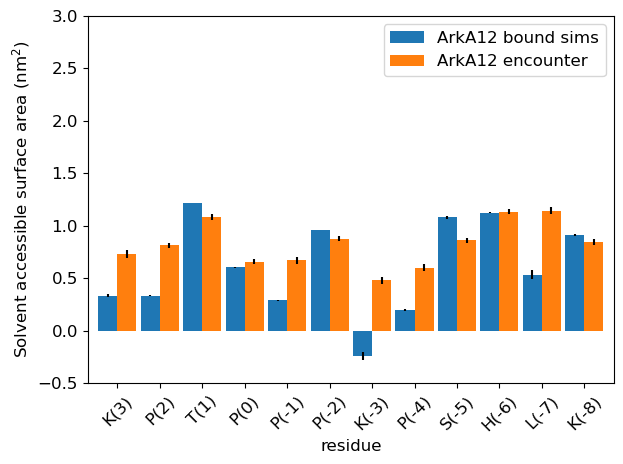

In [16]:
plt.figure(figsize=(5,4.5))
plt.rcParams.update({'font.size': 12})
ax1 = avg_surf.iloc[1:,0:4].plot(kind='bar', width=0.9, yerr=std_surf.iloc[1:,0:4])
ax1.set_ylim(-0.5,3)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)
ax1.set_ylabel("Solvent accessible surface area ($\mathregular{nm^2}$)")
ax1.set_xlabel("residue")
plt.tight_layout()
#plt.savefig('/data/kball/SH3_binding/binding_paper_analysis/hydrophobics/SASA2.pdf', dpi=1000)

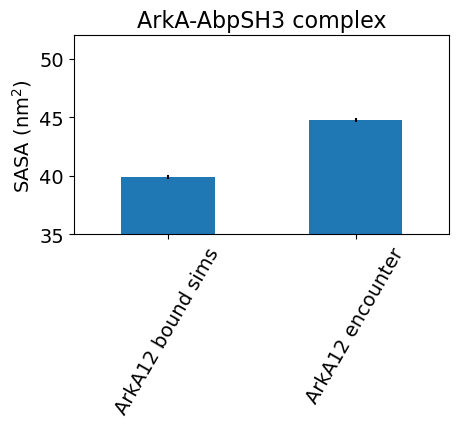

In [17]:
plt.figure(figsize=(5,4.5))
plt.rcParams.update({'font.size': 14})
ax2 = avg_surf.iloc[0].plot(kind='bar', width=0.5, yerr=std_surf.iloc[0])
ax2.set_ylim(35,52)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=60)
ax2.set_ylabel("SASA ($\mathregular{nm^2}$)")
plt.title('ArkA-AbpSH3 complex', fontsize=16)
plt.tight_layout()
#plt.savefig('/data/kball/SH3_binding/binding_paper_analysis/hydrophobics/SASA_total.pdf', dpi=1000)

# Salt calculations

In [18]:
salt_avg_surf = pd.DataFrame(columns=['ArkA12 bound sims'])
salt_bound_surf = salt_bound_surf.drop(['#Frame'], axis=1)
salt_avg_surf['ArkA12 bound sims'] = salt_bound_surf.mean()/100 # convert to nm^2
salt_avg_surf

,ArkA12 bound sims
SA_00001,39.930354
SA_00002,0.471698
SA_00003,0.291581
SA_00004,1.204391
SA_00005,0.632690
SA_00006,0.275492
SA_00007,0.958280
SA_00008,-0.176363
SA_00009,0.195456
SA_00010,1.078005


In [19]:
salt_std_surf = pd.DataFrame(columns=['ArkA12 bound sims'])
salt_num_bound_sims = 10
salt_num_bound_snapshots = int(len(salt_bound_surf)/salt_num_bound_sims)
salt_avg_surf_by_sim = pd.DataFrame(columns=[0])
for sim in range(0,salt_num_bound_sims):
    salt_avg_surf_by_sim[sim] = salt_bound_surf[sim*salt_num_bound_snapshots:(sim+1)*salt_num_bound_snapshots].mean()/100 # convert to nm^2
salt_std_surf['ArkA12 bound sims'] = salt_avg_surf_by_sim.sem(axis=1)
salt_std_surf

,ArkA12 bound sims
SA_00001,0.255167
SA_00002,0.012991
SA_00003,0.007537
SA_00004,0.001887
SA_00005,0.004135
SA_00006,0.004880
SA_00007,0.001653
SA_00008,0.060649
SA_00009,0.007831
SA_00010,0.010191


In [20]:
salt_binding_surf['status'] = salt_arka12_stat['status']

salt_encounter_surf = salt_binding_surf[(salt_binding_surf['status'] != 'unbound') & 
                                            (salt_binding_surf['status'] != 'Bound')]
salt_encounter_surf = salt_encounter_surf.drop(['#Frame', 'status'], axis=1)
salt_avg_surf['ArkA12 encounter'] = salt_encounter_surf.mean()/100 # convert to nm^2
salt_avg_surf

,ArkA12 bound sims,ArkA12 encounter
SA_00001,39.930354,45.379776
SA_00002,0.471698,0.743520
SA_00003,0.291581,0.717987
SA_00004,1.204391,1.028700
SA_00005,0.632690,0.730285
SA_00006,0.275492,0.708441
SA_00007,0.958280,0.814437
SA_00008,-0.176363,0.691773
SA_00009,0.195456,0.635648
SA_00010,1.078005,0.892722


In [21]:
salt_encounter_surf

,SA_00001,SA_00002,SA_00003,SA_00004,SA_00005,SA_00006,SA_00007,SA_00008,SA_00009,SA_00010,SA_00011,SA_00012,SA_00013
4142,4679.0636,117.7247,95.0966,126.9411,88.7883,95.4564,95.4374,53.2371,8.8886,93.6382,54.7555,58.4129,143.3626
4143,4589.6230,112.3529,96.1691,132.8829,80.0352,94.3264,99.1853,45.1065,12.3937,90.9437,58.3779,63.8196,126.6957
4146,4643.4347,128.4898,96.2062,130.9008,93.2072,95.8157,104.1734,46.0481,14.3421,97.8533,75.6680,73.6474,157.7197
4149,4625.6733,120.2187,95.7931,131.2625,84.1074,101.5494,96.8646,45.0664,7.4333,98.5350,58.9325,56.1664,161.0142
4150,4751.4574,133.7328,100.5908,133.3878,92.4704,85.4767,101.4297,62.7880,5.0624,100.8992,66.0132,67.4341,162.1852
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4999995,4753.9898,39.9530,31.3806,104.0072,99.7153,12.1193,86.4370,117.5439,106.3366,79.2547,138.4693,134.7159,146.0536
4999996,4642.3709,46.8230,34.6585,110.7375,92.0420,13.7429,88.0036,102.5038,102.4716,82.8609,139.2577,141.6217,144.7208
4999997,4767.2236,55.7397,47.7127,108.3285,83.1896,6.1195,95.8163,120.3428,94.0316,88.8969,134.4519,132.7702,151.9073
4999998,4836.9303,64.3492,30.5510,111.8083,84.7523,9.0024,98.9239,110.1493,95.1396,85.2192,141.8326,128.8838,152.5685


In [22]:
salt_num_binding_sims = 10
salt_num_binding_snapshots = int(len(salt_binding_surf)/salt_num_binding_sims)

salt_avg_surf_by_sim_encounter = pd.DataFrame(columns=[0])
for sim in range(0,salt_num_binding_sims):
    by_sim = salt_binding_surf[sim*salt_num_binding_snapshots:(sim+1)*salt_num_binding_snapshots]
    status_sim = by_sim[(by_sim['status'] != 'unbound') & (by_sim['status'] != 'Bound')]
    salt_avg_surf_by_sim_encounter[sim] = status_sim.iloc[:, :-1].mean()/100 # convert to nm^2
salt_std_surf['ArkA12 encounter'] = salt_avg_surf_by_sim_encounter.sem(axis=1)

salt_std_surf

,ArkA12 bound sims,ArkA12 encounter
SA_00001,0.255167,0.194463
SA_00002,0.012991,0.047372
SA_00003,0.007537,0.035695
SA_00004,0.001887,0.028710
SA_00005,0.004135,0.023190
SA_00006,0.004880,0.025935
SA_00007,0.001653,0.027225
SA_00008,0.060649,0.030253
SA_00009,0.007831,0.038312
SA_00010,0.010191,0.020383


In [23]:
salt_avg_surf = salt_avg_surf.rename(index={'SA_00001': 'total', 'SA_00002': 'K(3)', 'SA_00003': 'P(2)', 'SA_00004': 'T(1)',
                                 'SA_00005': 'P(0)', 'SA_00006': 'P(-1)', 'SA_00007': 'P(-2)', 'SA_00008': 'K(-3)',
                                 'SA_00009': 'P(-4)', 'SA_00010': 'S(-5)', 'SA_00011': 'H(-6)', 'SA_00012': 'L(-7)',
                                 'SA_00013': 'K(-8)'})
salt_avg_surf.round(1)

salt_avg_surf

,ArkA12 bound sims,ArkA12 encounter
total,39.930354,45.379776
K(3),0.471698,0.743520
P(2),0.291581,0.717987
T(1),1.204391,1.028700
P(0),0.632690,0.730285
P(-1),0.275492,0.708441
P(-2),0.958280,0.814437
K(-3),-0.176363,0.691773
P(-4),0.195456,0.635648
S(-5),1.078005,0.892722


In [24]:
salt_std_surf = salt_std_surf.rename(index={'SA_00001': 'total', 'SA_00002': 'K(3)', 'SA_00003': 'P(2)', 'SA_00004': 'T(1)',
                                 'SA_00005': 'P(0)', 'SA_00006': 'P(-1)', 'SA_00007': 'P(-2)', 'SA_00008': 'K(-3)',
                                 'SA_00009': 'P(-4)', 'SA_00010': 'S(-5)', 'SA_00011': 'H(-6)', 'SA_00012': 'L(-7)',
                                 'SA_00013': 'K(-8)'})
salt_std_surf.round(1)

salt_std_surf

,ArkA12 bound sims,ArkA12 encounter
total,0.255167,0.194463
K(3),0.012991,0.047372
P(2),0.007537,0.035695
T(1),0.001887,0.028710
P(0),0.004135,0.023190
P(-1),0.004880,0.025935
P(-2),0.001653,0.027225
K(-3),0.060649,0.030253
P(-4),0.007831,0.038312
S(-5),0.010191,0.020383


<Figure size 500x450 with 0 Axes>

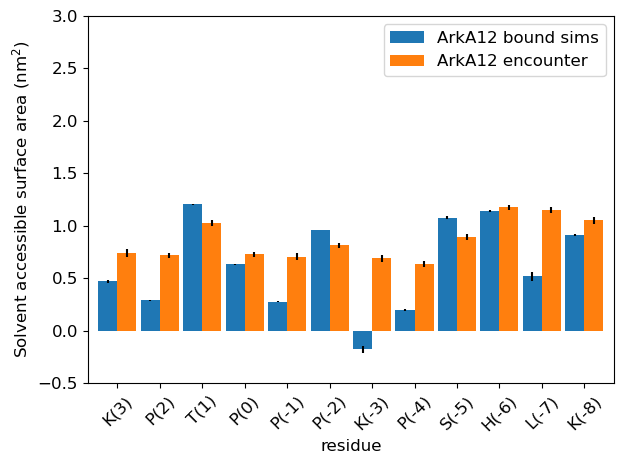

In [25]:
plt.figure(figsize=(5,4.5))
plt.rcParams.update({'font.size': 12})
ax1 = salt_avg_surf.iloc[1:,0:4].plot(kind='bar', width=0.9, yerr=std_surf.iloc[1:,0:4])
ax1.set_ylim(-0.5,3)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)
ax1.set_ylabel("Solvent accessible surface area ($\mathregular{nm^2}$)")
ax1.set_xlabel("residue")
plt.tight_layout()

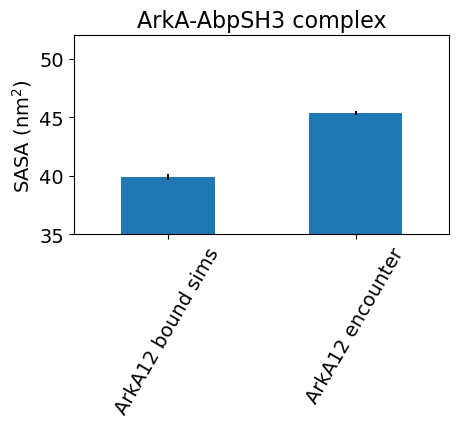

In [26]:
# Salt
plt.figure(figsize=(5,4.5))
plt.rcParams.update({'font.size': 14})
ax2 = salt_avg_surf.iloc[0].plot(kind='bar', width=0.5, yerr=salt_std_surf.iloc[0])
ax2.set_ylim(35,52)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=60)
ax2.set_ylabel("SASA ($\mathregular{nm^2}$)")
plt.title('ArkA-AbpSH3 complex', fontsize=16)
plt.tight_layout()

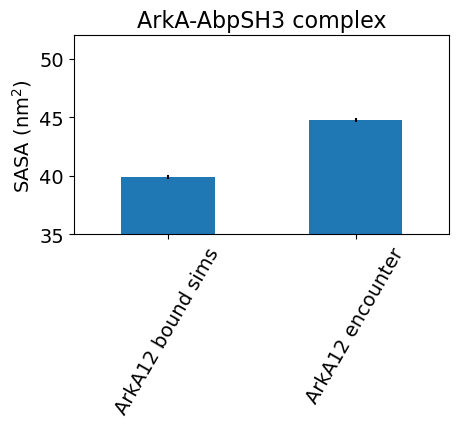

In [27]:
# No salt
plt.figure(figsize=(5,4.5))
plt.rcParams.update({'font.size': 14})
ax2 = avg_surf.iloc[0].plot(kind='bar', width=0.5, yerr=std_surf.iloc[0])
ax2.set_ylim(35,52)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=60)
ax2.set_ylabel("SASA ($\mathregular{nm^2}$)")
plt.title('ArkA-AbpSH3 complex', fontsize=16)
plt.tight_layout()

# Direct comparison

Current dimensions: 7.0 x 5.0 inches
New dimensions: 3.33 x 2.3785714285714286 inches


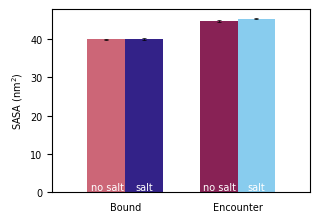

In [41]:
# CHANGE THIS TO REFLECT DATA FROM THIS NOTEBOOK

x = np.arange(1)  # X coordinates for each group

width = 0.41
sep = 0.2

plt.figure(figsize=(7,5))

# Plotting the bound (only for "nosalt sims")
plt.bar(x - 3*width/2 - sep, avg_surf.iloc[0,0], width, color='#CC6677',
        yerr=std_surf.iloc[0,0], error_kw={'elinewidth': 0.5, "capsize": 1.5, "capthick": 0.5}, linewidth=0.5)

# Plotting the bound (only for "salt sims")
plt.bar(x - width/2 - sep, salt_avg_surf.iloc[0,0], width, color='#332288',
        yerr=salt_std_surf.iloc[0,0], error_kw={'elinewidth': 0.5, "capsize": 1.5, "capthick": 0.5}, linewidth=0.5)

# Plotting the encounter (only for "nosalt sims")
plt.bar(x + width/2 + sep, avg_surf.iloc[0,1], width, color='#882255',
        yerr=std_surf.iloc[0,1], error_kw={'elinewidth': 0.5, "capsize": 1.5, "capthick": 0.5}, linewidth=0.5)

# Plotting the encounter (only for "salt sims")
plt.bar(x + 3*width/2 + sep, salt_avg_surf.iloc[0,1], width, color='#88CCEE',
        yerr=salt_std_surf.iloc[0,1], error_kw={'elinewidth': 0.5, "capsize": 1.5, "capthick": 0.5}, linewidth=0.5)

plt.xlim(-1 - 2*sep,1 + 2*sep)
#plt.ylim(0,8)
# Set x-axis ticks as original index
plt.xticks([-width - sep, width + sep], ["Bound", "Encounter"], fontsize=7)
plt.tick_params(bottom=False)

# Add legend, xlabel, ylabel, and title
plt.ylabel('SASA ($\mathregular{nm^2}$)', fontsize=7)
plt.text(-0.98, 0.5, "no salt", color='white', fontsize=7)
plt.text(-0.91+width, 0.5, "salt", color='white', fontsize=7)
plt.text(0.24, 0.5, "no salt", color='white', fontsize=7)
plt.text(0.31+width, 0.5, "salt", color='white', fontsize=7)
#plt.title('ArkA17 Bound', fontsize=18)

plt.xticks(fontsize=7)
plt.yticks(np.arange(0, 50, 10), fontsize=7)
# Get the current figure
fig = plt.gcf()

# Get the current dimensions
current_width, current_height = fig.get_size_inches()
print(f"Current dimensions: {current_width} x {current_height} inches")

# Define the new width
new_width = 3.33

# Calculate the new height to maintain the aspect ratio
aspect_ratio = current_height / current_width
new_height = new_width * aspect_ratio
print(f"New dimensions: {new_width} x {new_height} inches")

# Set the new figure size
fig.set_size_inches(new_width, new_height)

# Save the figure
plt.savefig('SASA_ArkA12.png', dpi=1000, bbox_inches='tight')

plt.show()

In [28]:
nosalt_minus_salt = avg_surf - salt_avg_surf
nosalt_minus_salt['ArkA17 bound sims'] = -0.25235593750898033 # taken from ArkA17 SASA notebook
cols = nosalt_minus_salt.columns.tolist()
cols = cols[-1:] + cols[:-1]
nosalt_minus_salt = nosalt_minus_salt[cols]
nosalt_minus_salt

,ArkA17 bound sims,ArkA12 bound sims,ArkA12 encounter
total,-0.252356,-0.005178,-0.635744
K(3),-0.252356,-0.139056,-0.011298
P(2),-0.252356,0.043352,0.095819
T(1),-0.252356,0.011327,0.054866
P(0),-0.252356,-0.028129,-0.073152
P(-1),-0.252356,0.017123,-0.038002
P(-2),-0.252356,0.002987,0.063368
K(-3),-0.252356,-0.062378,-0.210650
P(-4),-0.252356,0.000118,-0.033185
S(-5),-0.252356,0.005879,-0.030592


In [29]:
std = (std_surf**2 + salt_std_surf**2)**0.5
std['ArkA17 bound sims'] = 0.878097 # taken from ArkA17 SASA notebook
cols = std.columns.tolist()
cols = cols[-1:] + cols[:-1]
std = std[cols]
std

,ArkA17 bound sims,ArkA12 bound sims,ArkA12 encounter
total,0.878097,0.301131,0.251275
K(3),0.878097,0.019219,0.061420
P(2),0.878097,0.008569,0.044631
T(1),0.878097,0.002753,0.038136
P(0),0.878097,0.005119,0.033131
P(-1),0.878097,0.006639,0.039638
P(-2),0.878097,0.001997,0.035342
K(-3),0.878097,0.070184,0.046104
P(-4),0.878097,0.012021,0.049248
S(-5),0.878097,0.016847,0.033262


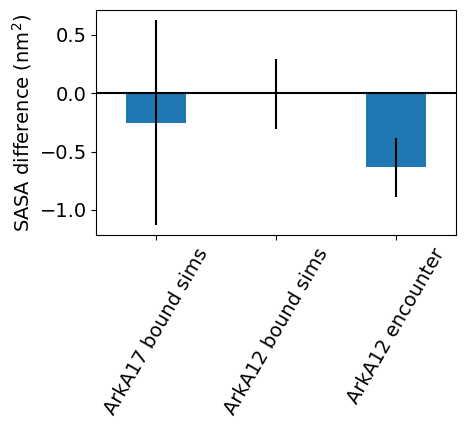

In [30]:
# No salt - salt
plt.figure(figsize=(5,4.5))
plt.rcParams.update({'font.size': 14})
ax2 = nosalt_minus_salt.iloc[0].plot(kind='bar', width=0.5, yerr=std.iloc[0])
#ax2.set_ylim(35,52)
plt.axhline(y=0, color='k', linestyle='-')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=60)
ax2.set_ylabel("SASA difference ($\mathregular{nm^2}$)")
#plt.title('SASA Difference (No salt - salt)', fontsize=16)
plt.tight_layout()

In [31]:
# Just bound
ArkA12_avg_hb_values = np.concatenate([bound_surf.iloc[:,0]/100, salt_bound_surf.iloc[:,0]/100])

#calculate the real difference, no salt minus salt
diff = nosalt_minus_salt.iloc[0,0]

print("ArkA12 bound 800 mM NaCl vs no-salt difference = " , diff)


#sample 10000 times and calculate differences
numsample = 10000
diff_samples = [0]*numsample
diff_samples_larger = [0]*numsample
for sample in range(0,len(diff_samples)):
    random_groups = np.random.permutation(ArkA12_avg_hb_values)
    diff_samples[sample] = (np.mean(random_groups[0:num_bound_sims]) 
             - np.mean(random_groups[num_bound_sims:num_bound_sims 
                                                + salt_num_bound_sims]))
    if diff_samples[sample] >= diff:
        diff_samples_larger[sample] = 1

#calculate p-value
pval_diff = (1 + np.sum(diff_samples_larger))/(numsample + 1)
print("p-value = " , pval_diff)


ArkA12 bound 800 mM NaCl vs no-salt difference =  -0.25235593750898033
p-value =  0.6117388261173883


In [32]:
# Just fully engaged
ArkA12_avg_hb_values = np.concatenate([ArkA12_binding_surf.iloc[:,0]/100, salt_binding_bound_surf.iloc[:,0]/100])

#calculate the real difference, no salt minus salt
diff = nosalt_minus_salt.iloc[0,1]

print("ArkA12 fully engaged 800 mM NaCl vs no-salt difference = " , diff)


#sample 10000 times and calculate differences
numsample = 10000
diff_samples = [0]*numsample
diff_samples_larger = [0]*numsample
for sample in range(0,len(diff_samples)):
    random_groups = np.random.permutation(ArkA12_avg_hb_values)
    diff_samples[sample] = (np.mean(random_groups[0:num_binding_sims]) 
             - np.mean(random_groups[num_binding_sims:num_binding_sims 
                                                + salt_num_binding_sims]))
    if diff_samples[sample] >= diff:
        diff_samples_larger[sample] = 1

#calculate p-value
pval_diff = (1 + np.sum(diff_samples_larger))/(numsample + 1)
print("p-value = " , pval_diff)

NameError: name 'salt_binding_bound_surf' is not defined

In [ ]:
# Just encounter
ArkA12_avg_hb_values = np.concatenate([ArkA12_encounter_surf.iloc[:,0]/100, salt_encounter_surf.iloc[:,0]/100])

#calculate the real difference, no salt minus salt
diff = nosalt_minus_salt.iloc[0,2]

print("ArkA12 encounter 800 mM NaCl vs no-salt difference = " , diff)


#sample 10000 times and calculate differences
numsample = 10000
diff_samples = [0]*numsample
diff_samples_larger = [0]*numsample
for sample in range(0,len(diff_samples)):
    random_groups = np.random.permutation(ArkA12_avg_hb_values)
    diff_samples[sample] = (np.mean(random_groups[0:num_binding_sims]) 
             - np.mean(random_groups[num_binding_sims:num_binding_sims 
                                                + salt_num_binding_sims]))
    if diff_samples[sample] >= diff:
        diff_samples_larger[sample] = 1

#calculate p-value
pval_diff = (1 + np.sum(diff_samples_larger))/(numsample + 1)
print("p-value = " , pval_diff)

In [ ]:
# Just unbound
ArkA12_avg_hb_values = np.concatenate([ArkA12_unbound_surf.iloc[:,0]/100, salt_unbound_surf.iloc[:,0]/100])

#calculate the real difference, no salt minus salt
diff = nosalt_minus_salt.iloc[0,0]

print("ArkA12 unbinding 800 mM NaCl vs no-salt difference = " , diff)


#sample 10000 times and calculate differences
numsample = 10000
diff_samples = [0]*numsample
diff_samples_larger = [0]*numsample
for sample in range(0,len(diff_samples)):
    random_groups = np.random.permutation(ArkA12_avg_hb_values)
    diff_samples[sample] = (np.mean(random_groups[0:num_binding_sims]) 
             - np.mean(random_groups[num_binding_sims:num_binding_sims 
                                                + salt_num_binding_sims]))
    if diff_samples[sample] >= diff:
        diff_samples_larger[sample] = 1

#calculate p-value
pval_diff = (1 + np.sum(diff_samples_larger))/(numsample + 1)
print("p-value = " , pval_diff)